# TURRET Kalman Filter Analysis Notebook

## Overview

Comprehensive analysis notebook for TURRET captured aircraft tracking and Kalman filter prediction data.

### Sections

1. **Setup and Imports**
2. **Data Loading** - Load captured session data
3. **Data Exploration** - Basic statistics and data quality
4. **Aircraft Tracking Analysis** - Track trajectories and continuity
5. **Kalman Filter Performance** - Covariance, errors, state transitions
6. **Statistical Analysis** - Aircraft counts, rates, stability
7. **Temporal Analysis** - Update intervals, timing, anomalies
8. **Configuration Analysis** - Compare configs and generate recommendations

### Setup

Before running:
- Activate the virtual environment: `source /home/leon/DEV/DOCKER/TURRET/notebooks/venv/bin/activate`
- Ensure capture data exists in the `captures/` directory

In [285]:
# Setup and Imports
import os
import sys
from pathlib import Path
from datetime import datetime

# Add modules to path
module_path = str(Path.cwd() / 'modules')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

# Import analysis modules
from modules.data_loader import DataLoader, create_data_loader
from modules.analysis import KalmanAnalysis, kalman_analysis
from modules.visualization import KalmanVisualizer, kalman_visualizer

# Core data science
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup complete!')
print(f'Module path: {module_path}')
print(f'Current directory: {Path.cwd()}')

Setup complete!
Module path: /home/leon/DEV/DOCKER/TURRET/notebooks/kalman-tuning/modules
Current directory: /home/leon/DEV/DOCKER/TURRET/notebooks/kalman-tuning


In [286]:
# Define captures directory
captures_dir = os.path.abspath(os.path.join('..', '..', 'captures'))

print(f'Captures directory: {captures_dir}')
print(f'Exists: {os.path.exists(captures_dir)}')

# Create data loader
data_loader = create_data_loader(captures_dir)
print('Data loader created!')

Captures directory: /home/leon/DEV/DOCKER/TURRET/captures
Exists: True
Data loader created!


## 1. Data Loading

Load captured data from the TURRET CSV storage backend.

In [287]:
# Find available dates
available_dates = data_loader.find_available_dates()
print('Available dates:')
for date in available_dates:
    print(f'  - {date}')

# Find sessions for latest date
if available_dates:
    latest_date = available_dates[0]
    sessions = data_loader.find_sessions_for_date(latest_date)
    print(f'Sessions for {latest_date}:')
    for session in sessions:
        print(f'  - {os.path.basename(session)}')

Available dates:
  - 2026-08-26
  - 2026-08-25
  - 2026-08-24
Sessions for 2026-08-26:
  - 2026-08-26_00-59-44_session_0000
  - 2026-08-26_00-42-12_session_0000
  - 2026-08-26_00-40-55_session_0000
  - 2026-08-26_00-40-50_session_0000
  - 2026-08-26_00-40-40_session_0000
  - 2026-08-26_00-38-49_session_0000
  - 2026-08-26_00-38-42_session_0000
  - 2026-08-26_00-38-35_session_0000
  - 2026-08-26_00-38-30_session_0000
  - 2026-08-26_00-29-49_session_0000
  - 2026-08-26_00-26-50_session_0000


In [288]:
# Load all data
print('Loading data...')
predictions, opensky, statistics, metadata_list = data_loader.load_all_data(limit=1)

print(f'Predictions: {len(predictions)} records')
print(f'OpenSky: {len(opensky)} records')
print(f'Statistics: {len(statistics)} records')
print(f'Sessions: {len(metadata_list)}')

# Show sample data
print('=== Predictions Sample ===')
display(predictions.head(3))

print('=== OpenSky Sample ===')
display(opensky.head(3))

Loading data...
Predictions: 529 records
OpenSky: 315 records
Statistics: 198 records
Sessions: 1
=== Predictions Sample ===


,timestamp,frame_index,session_id,callsign,latitude,longitude,baro_altitude,velocity,true_track,vertical_rate,covariance_lat,covariance_lon,covariance_alt,state,v_north,v_east
0,1.787699e+09,1,54140cc2-f5e1-453f-a33d-b0b76c5ad700,CCM35Q,43.723382,1.564993,2543.100347,103.44,88.58,5.85,1.144336e-07,2.191059e-07,1414.892316,tracking,2.563361,103.408234
1,1.787699e+09,1,54140cc2-f5e1-453f-a33d-b0b76c5ad700,TOM3EL,43.167266,1.554440,12495.623176,224.42,155.20,-0.33,1.142514e-07,2.148182e-07,1412.640244,tracking,-203.723422,94.133436
2,1.787699e+09,1,54140cc2-f5e1-453f-a33d-b0b76c5ad700,RYR9189,43.811671,1.689906,11887.200000,219.86,169.35,0.00,1.142357e-07,2.194253e-07,1412.446399,tracking,-216.072790,40.632118


=== OpenSky Sample ===


,timestamp,frame_index,session_id,callsign,latitude,longitude,baro_altitude,velocity,true_track,vertical_rate,on_ground,v_north,v_east
0,1.787699e+09,1,54140cc2-f5e1-453f-a33d-b0b76c5ad700,CCM35Q,43.7233,1.5604,2522.22,103.44,88.58,5.85,False,2.563361,103.408234
1,1.787699e+09,1,54140cc2-f5e1-453f-a33d-b0b76c5ad700,TOM3EL,43.1738,1.5503,12496.80,224.42,155.20,-0.33,False,-203.723422,94.133436
2,1.787699e+09,1,54140cc2-f5e1-453f-a33d-b0b76c5ad700,RYR9189,43.8186,1.6881,11887.20,219.86,169.35,0.00,False,-216.072790,40.632118


In [289]:
# Get combined summary
summary = data_loader.get_combined_summary(predictions, opensky, statistics, metadata_list)

print(f'Sessions: {summary["num_sessions"]}')
print(f'Total predictions: {summary["total_predictions"]}')
print(f'Unique callsigns: {summary["unique_callsigns_predictions"]}')
print(f'States: {summary["state_distribution"]}')

# Kalman configs
for i, config in enumerate(summary['kalman_configs']):
    print(f'Config {i+1}:')
    for k, v in config.items():
        print(f'  {k}: {v}')

Sessions: 1
Total predictions: 529
Unique callsigns: 5
States: {'tracking': 529}
Config 1:
  data_update_interval: 30.0
  prediction_interval: 2.0
  max_measurement_age: 60.0
  position_process_noise: 50.0
  velocity_process_noise: 50.0
  position_measurement_noise: 100.0


In [290]:
callsigns = opensky['callsign'].unique()
selected_callsign = callsigns[0]

## 2. Data Exploration

Basic statistics and data quality analysis.

In [291]:
# Basic statistics
pred_stats = kalman_analysis.get_basic_statistics(predictions)
os_stats = kalman_analysis.get_basic_statistics(opensky)

print('=== Predictions Statistics ===')
for col, stats in list(pred_stats.items())[:5]:
    print(f'{col}: mean={stats["mean"]:.2f}, std={stats["std"]:.2f}')

print('=== OpenSky Statistics ===')
for col, stats in list(os_stats.items())[:5]:
    print(f'{col}: mean={stats["mean"]:.2f}, std={stats["std"]:.2f}')

=== Predictions Statistics ===
timestamp: mean=1787698943.89, std=119.30
frame_index: mean=79.60, std=59.63
latitude: mean=43.58, std=0.24
longitude: mean=1.70, std=0.40
baro_altitude: mean=8473.24, std=4147.15
=== OpenSky Statistics ===
timestamp: mean=1787698924.96, std=94.21
frame_index: mean=70.14, std=47.09
latitude: mean=43.61, std=0.21
longitude: mean=1.73, std=0.30
baro_altitude: mean=7675.88, std=4277.05


In [292]:
# Identify data gaps
pred_gaps = kalman_analysis.identify_data_gaps(predictions)
os_gaps = kalman_analysis.identify_data_gaps(opensky)

print('=== Predictions Gaps ===')
print(f'Total records: {pred_gaps["total_records"]}')
print(f'Missing values: {pred_gaps["total_missing_values"]}')
print(f'Avg time between records: {pred_gaps["avg_time_between_records"]:.4f}s')
print(f'Max gap: {pred_gaps["max_gap"]:.4f}s')
print(f'Gaps > 1s: {pred_gaps["gaps_greater_than_1s"]}')
print(f'Gaps > 5s: {pred_gaps["gaps_greater_than_5s"]}')
print(f'Gaps > 10s: {pred_gaps["gaps_greater_than_10s"]}')

=== Predictions Gaps ===
Total records: 529
Missing values: 0
Avg time between records: 0.7426s
Max gap: 2.0076s
Gaps > 1s: 196
Gaps > 5s: 0
Gaps > 10s: 0


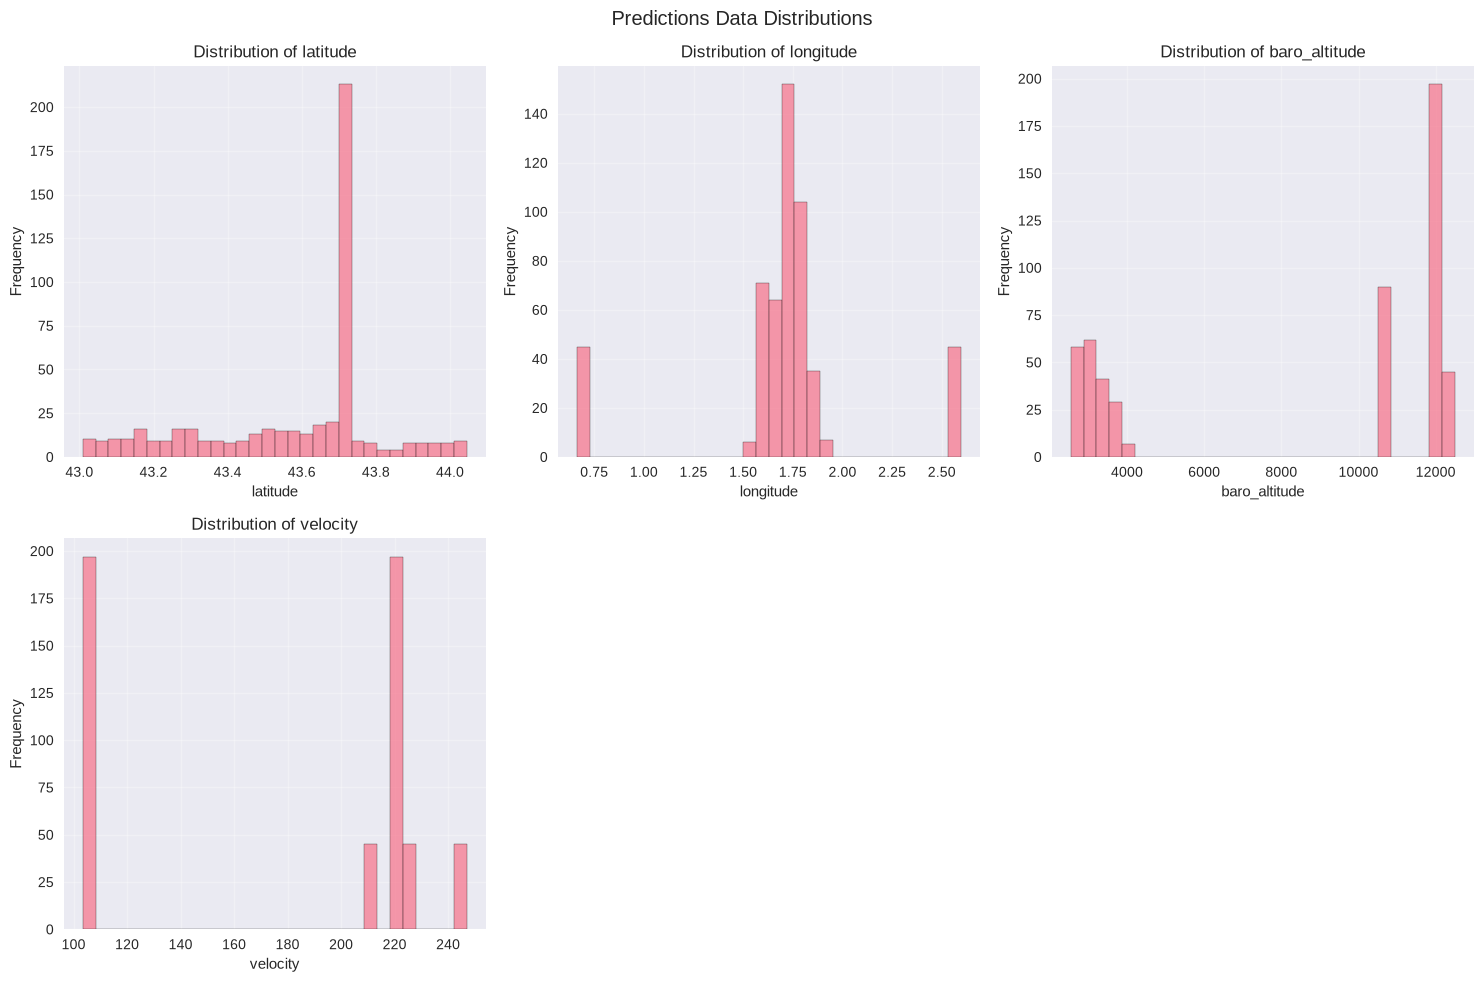

In [293]:
# Plot distributions
key_cols = ['latitude', 'longitude', 'baro_altitude', 'velocity']
plot_cols = [c for c in key_cols if c in predictions.columns]

fig, axes = kalman_visualizer.plot_distribution_histograms(predictions, plot_cols, bins=30)
plt.suptitle('Predictions Data Distributions')
plt.tight_layout()
plt.show()

## 3. Aircraft Tracking Analysis

Track individual aircraft and analyze trajectories.

In [294]:
# Get trajectories
trajectories = kalman_analysis.get_aircraft_trajectories(predictions)
print(f'Found {len(trajectories)} aircraft trajectories')

# Show first few
for callsign in list(trajectories.keys())[:5]:
    print(f'{callsign}: {len(trajectories[callsign])} predictions')

Found 5 aircraft trajectories
CCM35Q: 197 predictions
TOM3EL: 45 predictions
RYR9189: 197 predictions
BAW59: 45 predictions
DAH1083: 45 predictions


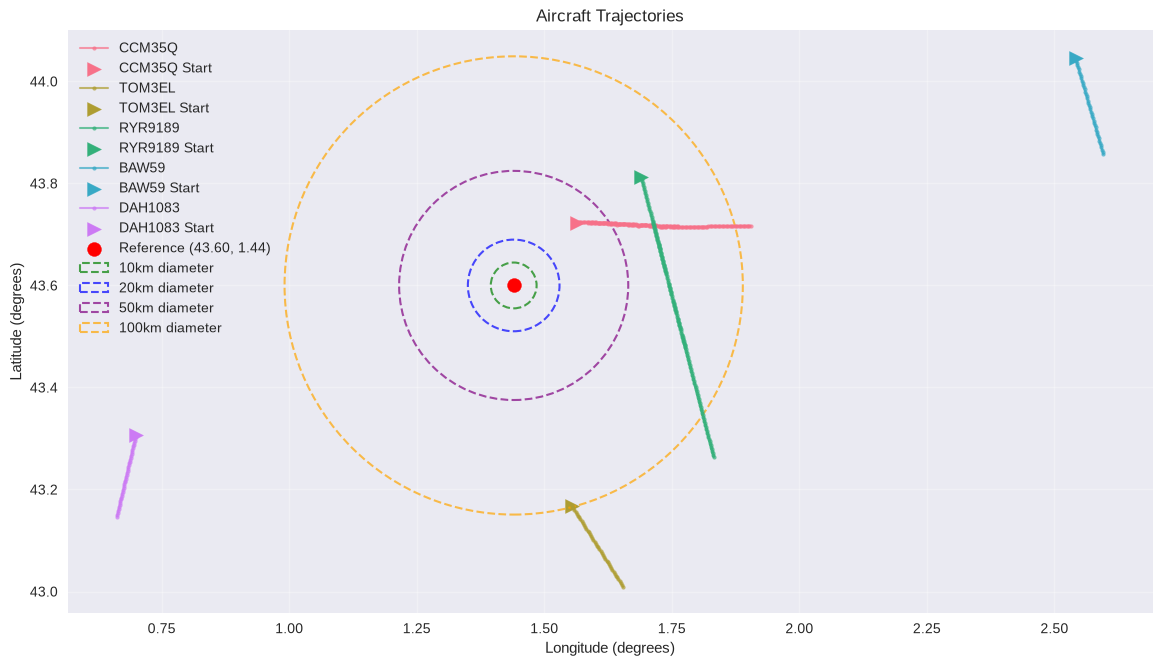

In [295]:
# Plot trajectories with reference point and range circles

if trajectories:
    sample_callsigns = list(trajectories.keys())[:min(10, len(trajectories))]
    sample_preds = predictions[predictions['callsign'].isin(sample_callsigns)]
    
    fig, ax = kalman_visualizer.plot_aircraft_trajectories(
        sample_preds, callsigns=sample_callsigns, figsize=(14, 10)
    )
    
    # Set equal aspect ratio so circles don't appear as ellipses
    ax.set_aspect('equal')
    
    # Reference point (Toulouse area)
    ref_lat = 43.60
    ref_lon = 1.44
    
    # Plot reference point
    ax.scatter(ref_lon, ref_lat, color='red', s=100, zorder=10, label='Reference (43.60, 1.44)')
    
    # Draw concentric circles with different diameters (10km, 20km, 50km, 100km)
    # Earth radius in km, 1 degree of lat/lon ~ 111.32 km
    km_per_degree = 111.32
    
    # Diameters in km and their corresponding radii in degrees
    diameters_km = [10, 20, 50, 100]
    colors = ['green', 'blue', 'purple', 'orange']
    labels = [f'{d}km diameter' for d in diameters_km]
    
    for diameter_km, color, label in zip(diameters_km, colors, labels):
        radius_km = diameter_km / 2
        radius_deg = radius_km / km_per_degree
        
        # Create circle patch
        circle = plt.Circle((ref_lon, ref_lat), radius_deg, 
                           fill=False, edgecolor=color, linestyle='--', 
                           linewidth=1.5, alpha=0.7, label=label)
        ax.add_patch(circle)
    
    # Adjust legend to include circles
    ax.legend(loc='best')
    
    plt.show()

In [296]:
# Track continuity analysis
continuity_results = []
for callsign, trajectory in trajectories.items():
    metrics = kalman_analysis.calculate_track_continuity(trajectory)
    continuity_results.append(metrics)

# Summary
if continuity_results:
    coverages = [m.track_coverage for m in continuity_results]
    print(f'Average track coverage: {np.mean(coverages):.2%}')
    print(f'Median track coverage: {np.median(coverages):.2%}')
    print(f'Average frames per aircraft: {np.mean([m.total_frames for m in continuity_results]):.1f}')

Average track coverage: 100.00%
Median track coverage: 100.00%
Average frames per aircraft: 105.8


In [297]:
# Track accuracy analysis
accuracy_metrics = kalman_analysis.analyze_track_accuracy(predictions, opensky)
print(f'Aircraft with comparison data: {len(accuracy_metrics)}')

# Overall error statistics
error_stats = kalman_analysis.calculate_prediction_error_statistics(predictions, opensky)
if error_stats:
    print(f'\nRMSE Position: {error_stats["rmse_position_m"]:.2f}m')
    print(f'MAE Position: {error_stats["mae_position_m"]:.2f}m')
    print(f'RMSE Altitude: {error_stats["rmse_altitude_m"]:.2f}m')
    print(f'RMSE Velocity: {error_stats["rmse_velocity_knots"]:.2f} knots')

Aircraft with comparison data: 5

RMSE Position: 10244.39m
MAE Position: 8228.12m
RMSE Altitude: 232.87m
RMSE Velocity: 5.47 knots


In [298]:
# Interactive 3D trajectory plot
# Try to import plotly for interactive visualization
try:
    import plotly.graph_objects as go
    from modules.visualization import plot_3d_trajectory_interactive
    has_plotly = True
except ImportError:
    has_plotly = False
    print('Plotly not available. Install with: pip install plotly')

if trajectories:
    sample_callsign = list(trajectories.keys())[0]
    # sample_callsign = "JAF6LD"
    trajectory = trajectories[sample_callsign]
    predictions_selected_callsign = predictions[predictions['callsign']==selected_callsign]
    
    if has_plotly:
        # Use interactive 3D plot with Plotly
        fig = plot_3d_trajectory_interactive(trajectory, callsign=sample_callsign)
        if fig:
            fig.show()
    else:
        # Fall back to matplotlib 3D plot
        fig = kalman_visualizer.plot_3d_trajectory(trajectory, callsign=sample_callsign)
        plt.show()

## 4. Kalman Filter Performance

Analyze covariance, prediction errors, and state transitions.

In [299]:
# Covariance convergence analysis
covariance_results = []
for callsign, trajectory in trajectories.items():
    if len(trajectory) >= 5:
        result = kalman_analysis.analyze_covariance_convergence(trajectory)
        covariance_results.append(result)

print(f'Analyzed {len(covariance_results)} aircraft')

# Summary
if covariance_results:
    rates = [r.convergence_rate for r in covariance_results]
    steady = [r.steady_state_reached for r in covariance_results]
    print(f'Avg convergence rate: {np.mean(rates):.2%}')
    print(f'Steady state reached: {sum(steady)}/{len(steady)} ({sum(steady)/len(steady)*100:.1f}%)')

Analyzed 5 aircraft
Avg convergence rate: -78493.75%
Steady state reached: 0/5 (0.0%)


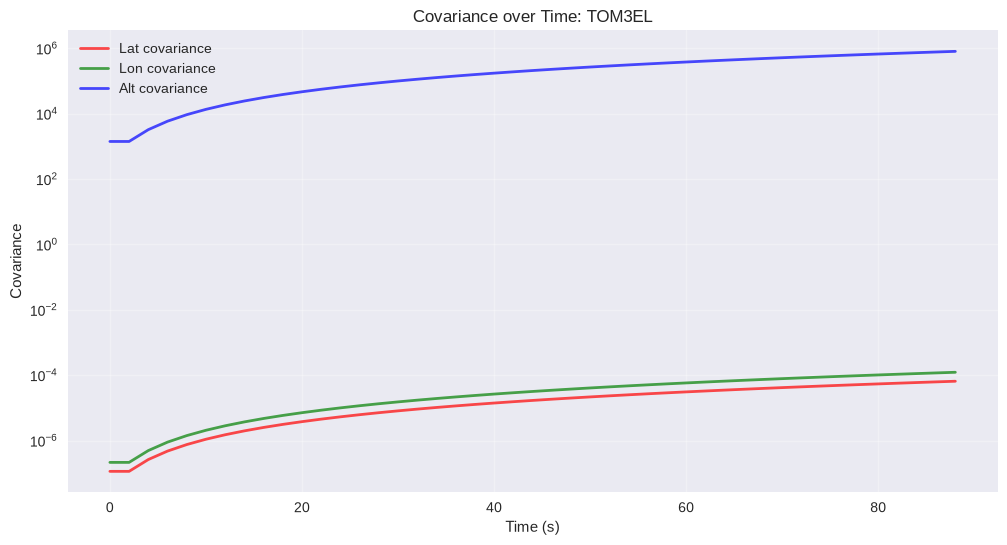

In [300]:
# Plot covariance
if covariance_results:
    best_idx = np.argmax([r.convergence_rate for r in covariance_results])
    best_callsign = covariance_results[best_idx].callsign
    best_traj = trajectories[best_callsign]
    
    fig, ax = kalman_visualizer.plot_covariance_over_time(best_traj, callsign=best_callsign)
    plt.show()

Transition counts:
  tracking->tracking: 524
State durations (s):
  tracking: 1048.30


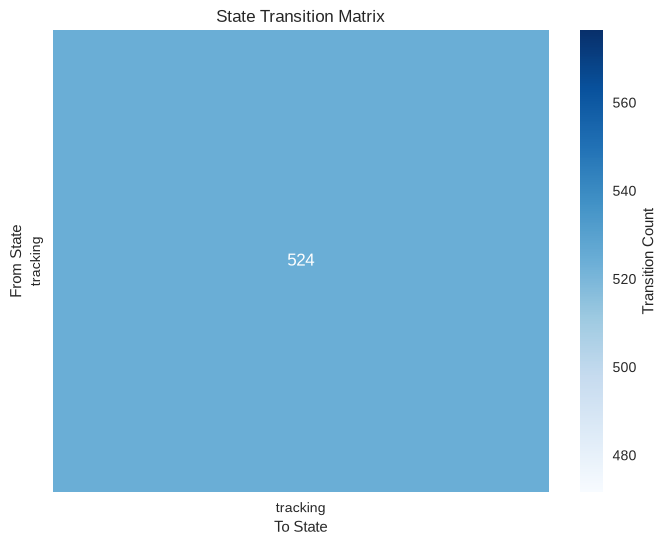

In [301]:
# State transition analysis
state_data = kalman_analysis.analyze_state_transitions(predictions)

print('Transition counts:')
for transition, count in state_data['transition_counts'].items():
    print(f'  {transition}: {count}')

print('State durations (s):')
for state, duration in state_data['state_durations'].items():
    print(f'  {state}: {duration:.2f}')

# Plot transition matrix
if not state_data['state_transition_matrix'].empty:
    fig, ax = kalman_visualizer.plot_state_transition_matrix(state_data['state_transition_matrix'])
    plt.show()

In [302]:
# Velocity vector accuracy
vel_metrics = kalman_analysis.analyze_velocity_vector_accuracy(predictions, opensky)

if vel_metrics:
    print(f'V North RMSE: {vel_metrics["v_north_rmse"]:.4f}')
    print(f'V East RMSE: {vel_metrics["v_east_rmse"]:.4f}')
    print(f'Velocity vector RMSE: {vel_metrics["velocity_vector_rmse"]:.4f}')

V North RMSE: 7.1076
V East RMSE: 4.8796
Velocity vector RMSE: 6.0962


,callsign,frame_index,timestamp_pred,session_id_pred,latitude_pred,longitude_pred,baro_altitude_pred,velocity_pred,true_track_pred,vertical_rate_pred,covariance_lat,covariance_lon,covariance_alt,state,v_north_pred,v_east_pred,timestamp_os,session_id_os,latitude_os,longitude_os,baro_altitude_os,velocity_os,true_track_os,vertical_rate_os,on_ground,v_north_os,v_east_os,lat_delta_deg,lon_delta_deg,alt_delta_m,horizontal_distance_m
0,BAW59,1,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.045246,2.541350,10668.000000,246.99,168.22,0.00,1.142280e-07,2.211470e-07,1412.350672,tracking,-241.788072,50.424083,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.0530,2.5391,10668.0,246.99,168.22,0.00,False,-241.788072,50.424083,0.007754,-0.002250,0.000000,0.880702
1,BAW59,2,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.045246,2.541350,10668.000000,246.99,168.22,0.00,1.142280e-07,2.211470e-07,1412.350672,tracking,-241.788072,50.424083,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.0530,2.5391,10668.0,246.99,168.22,0.00,False,-241.788072,50.424083,0.007754,-0.002250,0.000000,0.880702
2,BAW59,3,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.040880,2.542617,10668.000000,246.99,168.22,0.00,2.626505e-07,5.084950e-07,3247.492970,tracking,-241.788072,50.424083,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.0530,2.5391,10668.0,246.99,168.22,0.00,False,-241.788072,50.424083,0.012120,-0.003517,0.000000,1.376648
3,BAW59,4,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.036518,2.543883,10668.000000,246.99,168.22,0.00,4.760536e-07,9.216463e-07,5886.074772,tracking,-241.788072,50.424083,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.0530,2.5391,10668.0,246.99,168.22,0.00,False,-241.788072,50.424083,0.016482,-0.004783,0.000000,1.872118
4,BAW59,5,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.032154,2.545149,10668.000000,246.99,168.22,0.00,7.547373e-07,1.461182e-06,9331.806701,tracking,-241.788072,50.424083,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,44.0530,2.5391,10668.0,246.99,168.22,0.00,False,-241.788072,50.424083,0.020846,-0.006049,0.000000,2.367890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,TOM3EL,11,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.134211,1.575383,12489.669353,224.42,155.20,-0.33,3.787640e-06,7.121611e-06,46831.567365,tracking,-203.723422,94.133436,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.1738,1.5503,12496.8,224.42,155.20,-0.33,False,-203.723422,94.133436,0.039589,-0.025083,7.130647,4.849549
311,TOM3EL,12,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.130534,1.577713,12489.006936,224.42,155.20,-0.33,4.521834e-06,8.502060e-06,55909.368926,tracking,-203.723422,94.133436,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.1738,1.5503,12496.8,224.42,155.20,-0.33,False,-203.723422,94.133436,0.043266,-0.027413,7.793064,5.300086
312,TOM3EL,13,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.126863,1.580039,12488.345792,224.42,155.20,-0.33,5.319606e-06,1.000205e-05,65773.269681,tracking,-203.723422,94.133436,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.1738,1.5503,12496.8,224.42,155.20,-0.33,False,-203.723422,94.133436,0.046937,-0.029739,8.454208,5.749763
313,TOM3EL,14,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.123183,1.582371,12487.682880,224.42,155.20,-0.33,6.184698e-06,1.162862e-05,76469.537259,tracking,-203.723422,94.133436,1.787699e+09,54140cc2-f5e1-453f-a33d-b0b76c5ad700,43.1738,1.5503,12496.8,224.42,155.20,-0.33,False,-203.723422,94.133436,0.050617,-0.032071,9.117120,6.200646


/tmp/ipykernel_42665/2092949565.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)


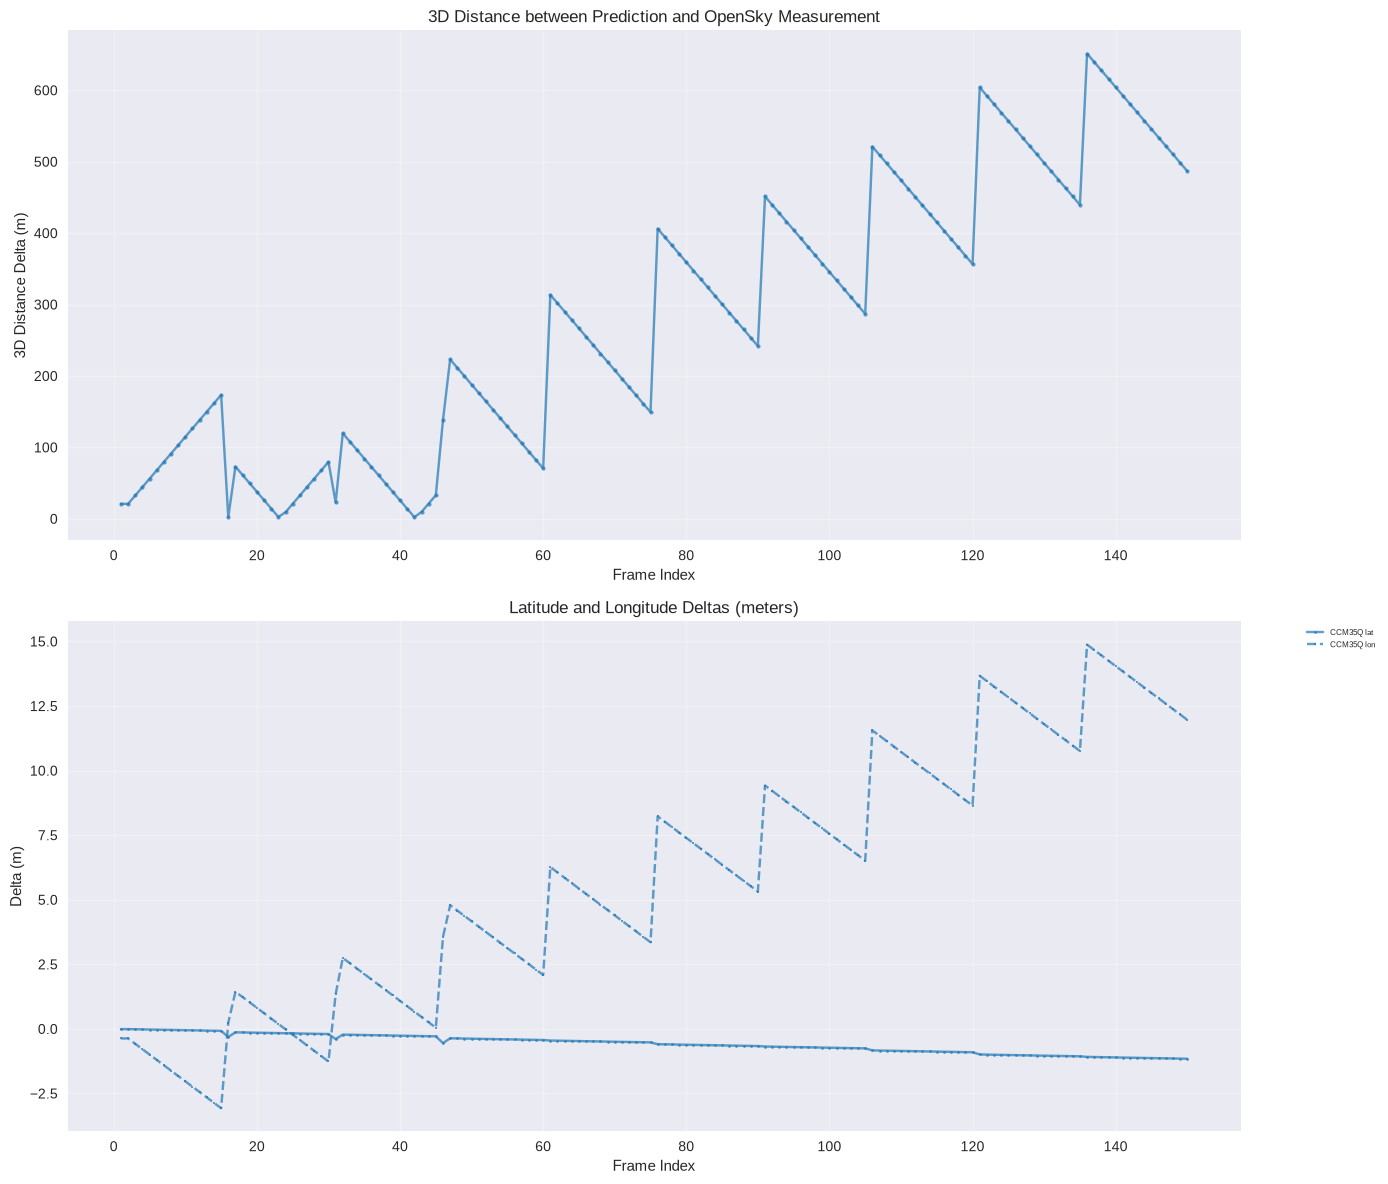

Number of matched (prediction, measurement) pairs: 315
Unique aircraft: 5

3D Distance Delta Statistics:
  Mean: 137.83 m
  Median: 20.88 m
  Std: 188.28 m
  Min: 0.54 m
  Max: 651.27 m

Horizontal Distance Statistics:
  Mean: 8.23 m
  Median: 6.92 m

Altitude Delta Statistics:
  Mean: 121.51 m
  Median: 0.00 m
  Std: 198.97 m


In [303]:
# Prediction vs Measurement Distance Delta Analysis
# Calculate the distance between latest predictions and latest OpenSky measurements

import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth radius in meters
    R = 6371.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Match predictions with OpenSky data by callsign and frame_index
# Get latest predictions and measurements for each aircraft at each frame
latest_preds = predictions.sort_values(['frame_index', 'timestamp']).groupby(['callsign', 'frame_index']).last().reset_index()
latest_os = opensky.sort_values(['frame_index', 'timestamp']).groupby(['callsign', 'frame_index']).last().reset_index()

# Merge on callsign and frame_index
merged = pd.merge(latest_preds, latest_os, on=['callsign', 'frame_index'], suffixes=('_pred', '_os'), how='inner')
# print("merged", merged)
if len(merged) > 0:
    # Calculate deltas
    merged['lat_delta_deg'] = merged['latitude_os'] - merged['latitude_pred']
    merged['lon_delta_deg'] = merged['longitude_os'] - merged['longitude_pred']
    merged['alt_delta_m'] = merged['baro_altitude_os'] - merged['baro_altitude_pred']

    # Calculate horizontal distance using haversine (in meters)
    merged['horizontal_distance_m'] = haversine_distance(
        merged['latitude_pred'].values, merged['longitude_pred'].values,
        merged['latitude_os'].values, merged['longitude_os'].values
    )

    display(merged)
    # Calculate 3D distance (in meters)
    merged['distance_3d_m'] = np.sqrt(merged['horizontal_distance_m']**2 + merged['alt_delta_m']**2)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # Plot 1: 3D Distance Delta over frames
    # Plot each aircraft with a different color
 
    cmap = plt.cm._colormaps.get_cmap('tab20')
    colors = cmap(np.linspace(0, 1, 1))
    selected_color = colors[0]
    callsign_data = merged[merged['callsign'] == selected_callsign]
    ax1.plot(callsign_data['frame_index'], callsign_data['distance_3d_m'], marker='o', markersize=3, alpha=0.7, color=selected_color)

    ax1.set_xlabel('Frame Index')
    ax1.set_ylabel('3D Distance Delta (m)')
    ax1.set_title('3D Distance between Prediction and OpenSky Measurement')
    ax1.grid(True, alpha=0.3)
    if len(selected_callsign) <= 20:
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    else:
        print(f'Skipping legend for {len(selected_callsign)} aircraft (too many for clear display)')

    # Plot 2: Latitude and Longitude Deltas (converted to meters)
    # callsign_data = merged[merged['callsign'] == selected_callsign]
    avg_lat = callsign_data['latitude_os'].mean()
    # Convert degrees to meters (111320 m per degree of lat, lon varies with latitude)
    lat_meters = callsign_data['lat_delta_deg'] * 111320
    lon_meters = callsign_data['lon_delta_deg'] * 111320 * np.cos(np.radians(avg_lat))
    ax2.plot(callsign_data['frame_index'], lat_meters/1000,
            marker='o', markersize=2, alpha=0.7, color=selected_color, label=f'{selected_callsign} lat')
    ax2.plot(callsign_data['frame_index'], lon_meters/1000,
            marker='s', markersize=2, alpha=0.7, color=selected_color, linestyle='--', label=f'{selected_callsign} lon')

    ax2.set_xlabel('Frame Index')
    ax2.set_ylabel('Delta (m)')
    ax2.set_title('Latitude and Longitude Deltas (meters)')
    ax2.grid(True, alpha=0.3)
    if len(selected_callsign) <= 10:
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
    else:
        print(f'Skipping legend for {len(selected_callsign)} aircraft (too many for clear display)')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f'Number of matched (prediction, measurement) pairs: {len(merged)}')
    print(f'Unique aircraft: {merged["callsign"].nunique()}')
    print(f'\n3D Distance Delta Statistics:')
    print(f'  Mean: {merged["distance_3d_m"].mean():.2f} m')
    print(f'  Median: {merged["distance_3d_m"].median():.2f} m')
    print(f'  Std: {merged["distance_3d_m"].std():.2f} m')
    print(f'  Min: {merged["distance_3d_m"].min():.2f} m')
    print(f'  Max: {merged["distance_3d_m"].max():.2f} m')
    print(f'\nHorizontal Distance Statistics:')
    print(f'  Mean: {merged["horizontal_distance_m"].mean():.2f} m')
    print(f'  Median: {merged["horizontal_distance_m"].median():.2f} m')
    print(f'\nAltitude Delta Statistics:')
    print(f'  Mean: {merged["alt_delta_m"].mean():.2f} m')
    print(f'  Median: {merged["alt_delta_m"].median():.2f} m')
    print(f'  Std: {merged["alt_delta_m"].std():.2f} m')
else:
    print('No matching prediction-measurement pairs found')

## 5. Statistical Analysis

Aircraft counts, prediction rates, and stability metrics.

In [304]:
# Aircraft count over time
count_data = kalman_analysis.analyze_aircraft_count(statistics)

if len(count_data) > 0:
    fig, ax = kalman_visualizer.plot_aircraft_count(count_data)
    plt.show()
    
    print(f'Max count: {count_data["count"].max():.0f}')
    print(f'Mean count: {count_data["count"].mean():.1f}')
else:
    print('No aircraft count data')

ValueError: Invalid frequency: 1S. Failed to parse with error message: ValueError("Invalid frequency: S. Failed to parse with error message: KeyError('S'). Did you mean s?")

In [ ]:
# Prediction measurement rates
rate_data = kalman_analysis.analyze_prediction_measurement_rates(statistics)

if rate_data:
    print(f'Avg time between frames: {rate_data["avg_time_between_frames"]:.4f}s')
    print(f'Avg predictions per frame: {rate_data["avg_predictions_per_frame"]:.2f}')
    print(f'Total predictions: {rate_data["total_predictions"]}')
    print(f'Total measurements: {rate_data["total_measurements"]}')

In [ ]:
# Track stability metrics
stability = kalman_analysis.calculate_track_stability_metrics(predictions)

if stability:
    print(f'Avg position jump: {stability["avg_position_jump_m"]:.2f}m')
    print(f'Max position jump: {stability["max_position_jump_m"]:.2f}m')
    print(f'Large jumps (>1km): {stability["large_jumps_count"]}')

Avg position jump: 560.56m
Max position jump: 4285.03m
Large jumps (>1km): 210


In [ ]:
# Altitude distribution
alt_data = kalman_analysis.analyze_altitude_distribution(predictions)

if alt_data:
    print(f'Mean altitude: {alt_data["mean_altitude_m"]:.2f}m')
    print(f'Max altitude: {alt_data["max_altitude_m"]:.2f}m')
    print(f'Max climb rate: {alt_data["max_climb_rate_mps"]:.2f}m/s')
    print(f'Max descent rate: {alt_data["max_descent_rate_mps"]:.2f}m/s')

Mean altitude: 10213.67m
Max altitude: 12237.08m
Max climb rate: 230.78m/s
Max descent rate: -60.79m/s


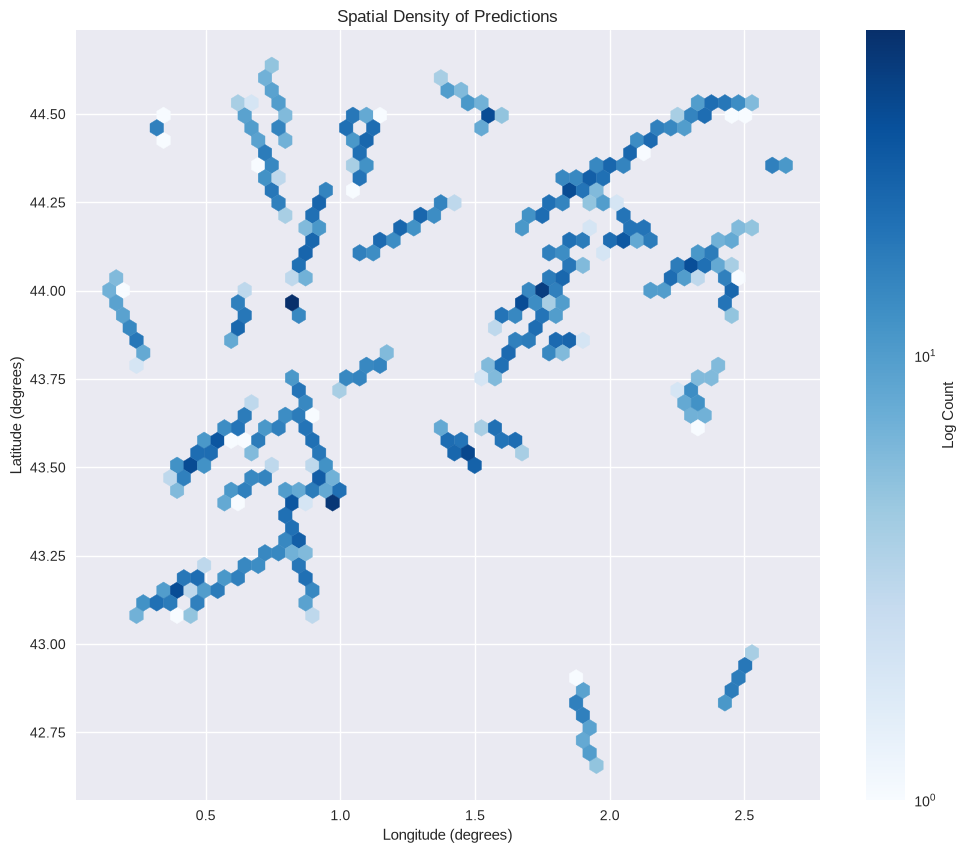

In [ ]:
# Spatial density heatmap
if len(predictions) > 0:
    fig, ax = kalman_visualizer.plot_spatial_density_heatmap(predictions, bins=50)
    plt.show()

## 6. Temporal Analysis

Update intervals, timing consistency, and anomalies.

In [ ]:
# Update interval analysis
if len(statistics) > 0:
    interval_data = kalman_analysis.analyze_update_intervals(statistics)
else:
    mock_stats = predictions.groupby('timestamp').size().reset_index(name='track_count')
    mock_stats['prediction_count'] = mock_stats['track_count']
    mock_stats['total_predictions'] = mock_stats['track_count'].cumsum()
    mock_stats['total_measurements'] = mock_stats['track_count'].cumsum()
    mock_stats['frame_index'] = range(len(mock_stats))
    mock_stats['session_id'] = predictions['session_id'].iloc[0]
    display(mock_stats)
    interval_data = kalman_analysis.analyze_update_intervals(mock_stats)

if interval_data:
    print(f'Mean interval: {interval_data["mean_interval_s"]:.4f}s')
    print(f'Std interval: {interval_data["std_interval_s"]:.4f}s')
    print(f'Intervals > 1s: {interval_data["intervals_greater_than_1s"]}')
    print(f'Intervals > 5s: {interval_data["intervals_greater_than_5s"]}')

,timestamp,track_count,prediction_count,total_predictions,total_measurements,frame_index,session_id
0,1.787581e+09,21,21,21,21,0,65105b2d-0043-4730-a2ae-6794e692ee9e
1,1.787581e+09,21,21,42,42,1,65105b2d-0043-4730-a2ae-6794e692ee9e
2,1.787581e+09,21,21,63,63,2,65105b2d-0043-4730-a2ae-6794e692ee9e
3,1.787581e+09,21,21,84,84,3,65105b2d-0043-4730-a2ae-6794e692ee9e
4,1.787581e+09,21,21,105,105,4,65105b2d-0043-4730-a2ae-6794e692ee9e
...,...,...,...,...,...,...,...
216,1.787692e+09,15,15,3892,3892,216,65105b2d-0043-4730-a2ae-6794e692ee9e
217,1.787692e+09,15,15,3907,3907,217,65105b2d-0043-4730-a2ae-6794e692ee9e
218,1.787692e+09,15,15,3922,3922,218,65105b2d-0043-4730-a2ae-6794e692ee9e
219,1.787692e+09,15,15,3937,3937,219,65105b2d-0043-4730-a2ae-6794e692ee9e


Mean interval: 503.4025s
Std interval: 7436.9933s
Intervals > 1s: 220
Intervals > 5s: 1


In [ ]:
# Timing consistency
if len(statistics) > 0:
    timing = kalman_analysis.analyze_frame_timing_consistency(statistics)
else:
    timing = kalman_analysis.analyze_frame_timing_consistency(mock_stats)

if timing:
    print(f'Expected interval: {timing["expected_interval_s"]:.4f}s')
    print(f'Jitter coefficient: {timing["jitter_coefficient"]:.2%}')

Expected interval: 503.4025s
Jitter coefficient: 1477.35%


Anomalous intervals: 1


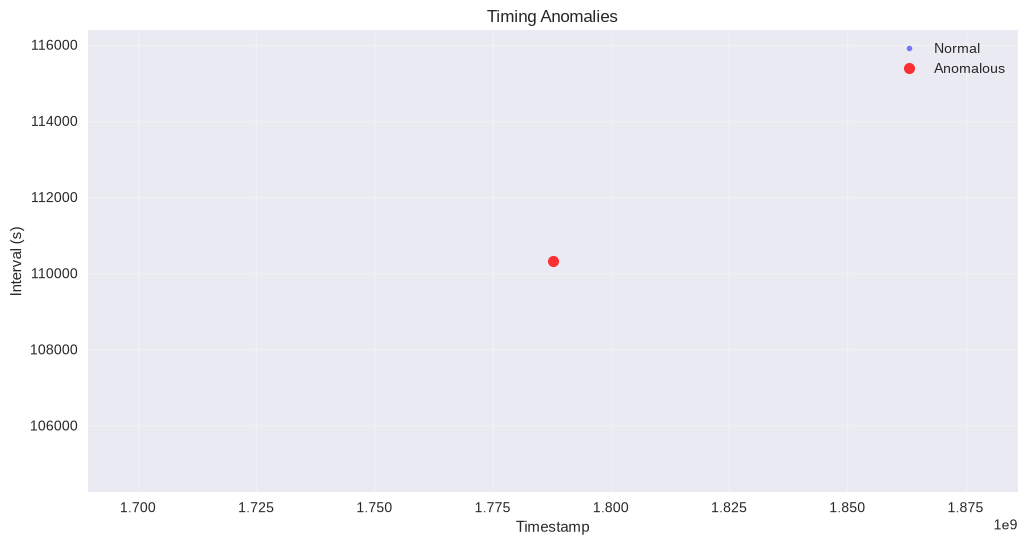

In [ ]:
# Timing anomalies
if len(statistics) > 0:
    anomalies = kalman_analysis.identify_timing_anomalies(statistics)
else:
    anomalies = kalman_analysis.identify_timing_anomalies(mock_stats)

print(f'Anomalous intervals: {len(anomalies)}')

if len(anomalies) > 0:
    fig, ax = kalman_visualizer.plot_timing_anomalies(anomalies)
    plt.show()

## 7. Configuration Analysis

Compare configurations and generate tuning recommendations.

In [ ]:
# Compare configurations
config_comp = kalman_analysis.compare_configurations(metadata_list)

print(f'Unique configurations: {config_comp["unique_configs"]}')

for i, config in enumerate(config_comp['configurations']):
    print(f'\nConfig {i+1}: {config["session_count"]} sessions')
    print(f'  Process Noise: {config["position_process_noise"]}')
    print(f'  Measurement Noise: {config["position_measurement_noise"]}')

Unique configurations: 2

Config 1: 1 sessions
  Process Noise: 50.0
  Measurement Noise: 100.0

Config 2: 1 sessions
  Process Noise: 10.0
  Measurement Noise: 100.0


In [ ]:
# Generate recommendations
recommendations = kalman_analysis.generate_configuration_recommendations(
    predictions, opensky, metadata_list
)

print('=== Configuration Recommendations ===')
if recommendations:
    for param, rec in recommendations['recommendations'].items():
        priority = recommendations['priority'].get(param, 'LOW')
        print(f'\n[{priority}] {param}: {rec}')

=== Configuration Recommendations ===

[HIGH] position_process_noise: Increase position process noise to allow for more uncertainty in position changes

[HIGH] altitude_process_noise: Increase altitude process noise or check vertical rate measurement accuracy

[MEDIUM] velocity_process_noise: Velocity process noise appears adequate

[HIGH] measurement_noise: Increase measurement noise to account for higher measurement uncertainty

[MEDIUM] update_interval: Increase update interval or improve timing consistency for better predictions


In [ ]:
# Process noise impact
noise_data = kalman_analysis.analyze_process_noise_impact(predictions, metadata_list)

if noise_data:
    print('Process noise levels:', noise_data['noise_levels'])
    for noise, metrics in noise_data['metrics'].items():
        print(f'Noise={noise}: Avg Lat Cov={metrics["avg_covariance_lat"]:.2e}')

Process noise levels: [50.0, 10.0]
Noise=50.0: Avg Lat Cov=4.81e-06
Noise=10.0: Avg Lat Cov=8.89e-07


## 8. Next Steps

### What to do next:

1. Review analysis results and recommendations
2. Tune Kalman filter parameters based on recommendations
3. Run new capture sessions with updated configurations
4. Re-run this notebook to compare performance

### Resources:

- [Kalman Filter Theory](https://en.wikipedia.org/wiki/Kalman_filter)
- TURRET Documentation

---

**Notebook Version**: 1.0.0 | **Last Updated**: 2026-08-24